# 第 12 章 · MCTS / UCT 代码实验

[章节网页](../ch12.html)

## 运行内容

- 准备 Tic-tac-toe 局面
- 计算探索项
- 绘制 UCT 分数

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# Tic-tac-toe 井字棋局面：用 UCT 在候选落子中平衡价值和探索。
board = np.array([
    ["X", "O", "X"],
    [" ", "O", " "],
    [" ", "X", " "],
])
candidate_moves = [(1, 0), (1, 2), (2, 0), (2, 2)]
parent_visits = 128
moves = pd.DataFrame(
    {
        "走法": [f"({r},{c})" for r, c in candidate_moves],
        "访问次数": [42, 30, 34, 22],
        "累计价值": [24.8, 16.2, 24.0, 11.5],
    }
)
explore_c = 1.4
moves["平均价值"] = moves["累计价值"] / moves["访问次数"]
moves["探索项"] = explore_c * np.sqrt(np.log(parent_visits) / moves["访问次数"])
moves["UCT"] = moves["平均价值"] + moves["探索项"]
moves = moves.sort_values("UCT", ascending=False).reset_index(drop=True)
display(pd.DataFrame(board))
display(moves.round(3))
print("选择走法:", moves.loc[0, "走法"])

,0,1,2
0,X,O,X
1,,O,
2,,X,


,走法,访问次数,累计价值,平均价值,探索项,UCT
0,"(2,0)",34,24.0,0.706,0.529,1.235
1,"(2,2)",22,11.5,0.523,0.657,1.180
2,"(1,2)",30,16.2,0.540,0.563,1.103
3,"(1,0)",42,24.8,0.590,0.476,1.066


选择走法: (2,0)


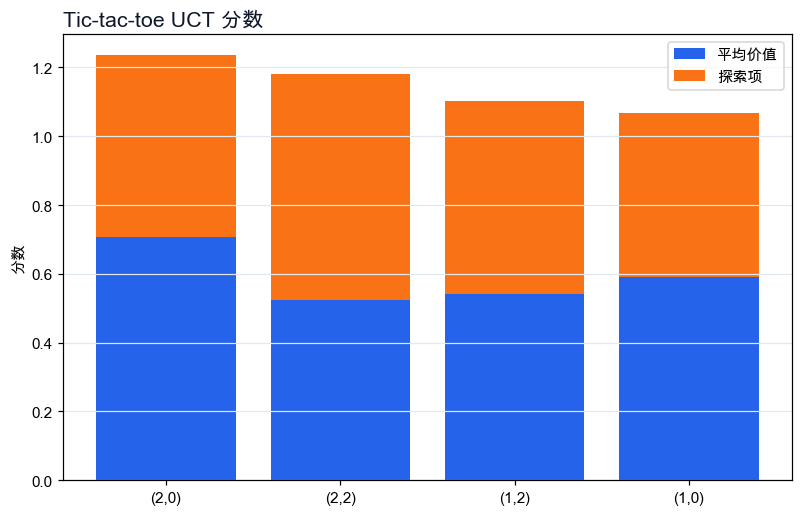

In [3]:
# 绘制 UCT 组成。
fig, ax = plt.subplots(figsize=(7.4, 4.8))
x = np.arange(len(moves))
ax.bar(x, moves["平均价值"], label="平均价值", color="#2563eb")
ax.bar(x, moves["探索项"], bottom=moves["平均价值"], label="探索项", color="#f97316")
ax.set_xticks(x, moves["走法"])
ax.set_title("Tic-tac-toe UCT 分数", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_ylabel("分数")
ax.grid(True, axis="y", color="#e2e8f0", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()